In [1]:
!pip install ultralytics
!pip install roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NMVli3YwBR2SldmWnurA")
project = rf.workspace("dock-vdcx1").project("my-first-project-8wzpq")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-1 in yolov11:: 100%|██████████| 7340/7340 [00:01<00:00, 7098.83it/s]


In [3]:
from ultralytics import YOLO

# Load a stronger YOLOv8 model (small or medium for better accuracy)
model = YOLO("yolo11m.pt")  # you can also try yolov8m.pt if GPU allows

# Start training
model.train(
    data=dataset.location + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,  # reduce to 8 or 4 if you get OOM error
    workers=2,
    device=0,  # use GPU if available
    name="rf_yolo8s_optimized",
    project="/content/yolo_rf_training",
    patience=10,  # early stopping
    augment=True,  # enables data augmentation
    hsv_h=0.015,  # hue augmentation
    hsv_s=0.7,    # saturation
    hsv_v=0.4,    # brightness
    scale=0.5,    # scale variation
    mosaic=1.0,   # keep mosaic on
    mixup=0.2,    # slight mixup for robustness
    degrees=0.1,  # light rotation
    translate=0.1,
    flipud=0.2,
    fliplr=0.5,
    lr0=0.01  # initial learning rate
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 38.8M/38.8M [00:00<00:00, 298MB/s]


Ultralytics 8.3.154 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-1/data.yaml, degrees=0.1, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=rf_yolo8s_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pos

100%|██████████| 755k/755k [00:00<00:00, 28.6MB/s]

Overriding model.yaml nc=80 with nc=8

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

...

                   all        387        854      0.638       0.67      0.687      0.636



50 epochs completed in 1.665 hours.
Optimizer stripped from /content/yolo_rf_training/rf_yolo8s_optimized/weights/last.pt, 40.5MB
Optimizer stripped from /content/yolo_rf_training/rf_yolo8s_optimized/weights/best.pt, 40.5MB

Validating /content/yolo_rf_training/rf_yolo8s_optimized/weights/best.pt...
Ultralytics 8.3.154 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,036,200 parameters, 0 gradients, 67.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:13<00:00,  1.04s/it]


                   all        387        854      0.718      0.629        0.7      0.645
                   Bag        102        145      0.793      0.807      0.825      0.731
                Bottle         55         74      0.814       0.73      0.806       0.78
                   Box         65         78      0.791      0.678      0.724      0.713
                   Cap         65        257       0.76      0.654      0.776      0.705
           Credit Card         67         68      0.696      0.353      0.509      0.475
                   Cup         83        164      0.627       0.64      0.614      0.561
               Cutlery         23         29       0.68      0.552      0.689      0.622
            Toothbrush         29         39      0.589      0.615      0.654      0.576
Speed: 0.3ms preprocess, 27.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/yolo_rf_training/rf_yolo8s_optimized


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7d4467b3d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [4]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/yolo_rf_training/rf_yolo8s_optimized/weights/best.pt")

# Run validation to generate confusion matrix, PR curve, etc.
metrics = model.val()


Ultralytics 8.3.154 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,036,200 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1491.1±539.1 MB/s, size: 43.2 KB)


val: Scanning /content/My-First-Project-1/valid/labels.cache... 387 images, 9 backgrounds, 0 corrupt: 100%|██████████| 387/387 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:13<00:00,  1.86it/s]


                   all        387        854        0.7      0.616      0.694      0.641
                   Bag        102        145      0.823      0.771      0.815      0.712
                Bottle         55         74      0.805      0.716      0.781      0.746
                   Box         65         78      0.728      0.641      0.708      0.692
                   Cap         65        257      0.779      0.654      0.777       0.73
           Credit Card         67         68      0.651      0.338      0.502      0.466
                   Cup         83        164      0.595      0.628      0.612      0.565
               Cutlery         23         29      0.678      0.581      0.696      0.634
            Toothbrush         29         39      0.538      0.597      0.662      0.583
Speed: 0.8ms preprocess, 26.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val


In [6]:
results = model.predict(source="/content/My-First-Project-1/test/images/-18-_jpg.rf.c89b8aa5553b25e2daf2414398fe36da.jpg", save=True, conf=0.25)

for r in results:
    print(f"\n🖼️ File: {r.path}")
    boxes = r.boxes
    for box in boxes:
        cls = int(box.cls[0])  # class index
        conf = float(box.conf[0])  # confidence
        xyxy = box.xyxy[0].tolist()  # bounding box coordinates
        print(f" → Class: {model.names[cls]} | Confidence: {conf:.2f} | Box: {xyxy}")


image 1/1 /content/My-First-Project-1/test/images/-18-_jpg.rf.c89b8aa5553b25e2daf2414398fe36da.jpg: 640x640 1 Box, 37.9ms
Speed: 3.1ms preprocess, 37.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict

🖼️ File: /content/My-First-Project-1/test/images/-18-_jpg.rf.c89b8aa5553b25e2daf2414398fe36da.jpg
 → Class: Box | Confidence: 0.94 | Box: [87.93861389160156, 163.22842407226562, 576.04345703125, 442.2546691894531]


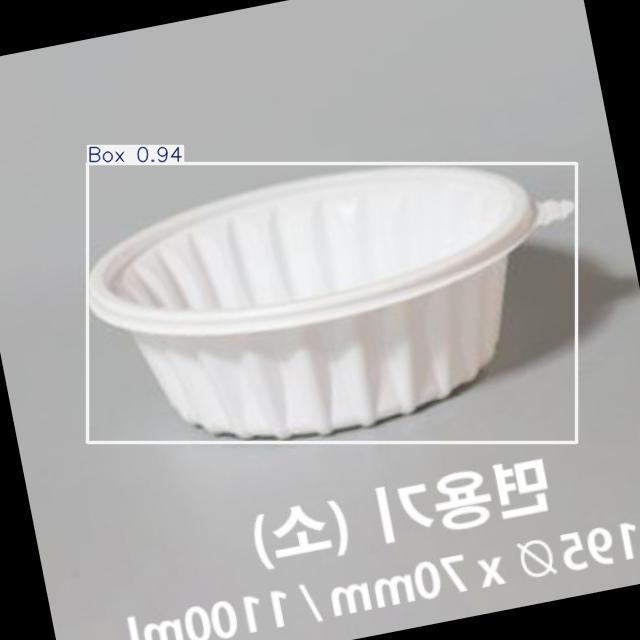

In [7]:
import os
from IPython.display import Image, display

# Get the prediction folder path (usually runs/detect/predict or predict2, etc.)
pred_folder = "/content/runs/detect/predict"

# List images in the prediction folder
pred_images = [f for f in os.listdir(pred_folder) if f.endswith(('.jpg', '.png'))]

# Display all predicted images (first 5 for example)
for img_name in pred_images[:5]:
    img_path = os.path.join(pred_folder, img_name)
    display(Image(filename=img_path))
